In [2]:
import os, glob, shutil
import urllib.request as r

In [15]:
def data_yuklab_olish(saqlash_uchun_papka, data_nomi = "humanitarian"):

    data_nomlari = [ "humanitarian", "customer"]
    assert data_nomi in data_nomlari, f"Mavjud bo'lgan dataset {data_nomlari} dan birini kiriting!"


    if data_nomi == "humanitarian": url = "https://drive.google.com/file/d/1dRv0-5iflumJFcjSHk-Vnjedtsn0WEEQ/view?usp=drive_link"
    elif data_nomi == "customer": url = "https://drive.google.com/file/d/1kW9UY7LI7kbnM5z2jgCMBUPUUMbsPe6p/view?usp=drive_link"

    full_path = f"{saqlash_uchun_papka}/{data_nomi}.zip"
    os.makedirs(saqlash_uchun_papka, exist_ok = True)

    # Download from the checkpoint path
    if os.path.isfile(f"{saqlash_uchun_papka}/{data_nomi}.csv"): print("Data yuklab olingan"); pass

    # If the checkpoint does not exist
    else:
        print("Datani yuklash boshlanmoqda...")

        # Get file id
        file_id = url.split("/")[-2]

        # Initialize prefix to download
        prefix = "https://drive.google.com/uc?/export=download&id="

        # Download the checkpoint
        r.urlretrieve(f"{prefix + file_id}", f"{full_path}")
        shutil.unpack_archive(f"{full_path}", f"{saqlash_uchun_papka}")
        os.remove(full_path)

        files = sorted(glob.glob(f"{saqlash_uchun_papka}/*"), key = os.path.getctime)
        fname = os.path.basename(files[-1])
        os.rename(f"{saqlash_uchun_papka}/{fname}", f"{saqlash_uchun_papka}/{data_nomi}.csv")
        print(f"Data {saqlash_uchun_papka} papkasiga {data_nomi} nomi bilan yuklab olindi.")

In [17]:
data_yuklab_olish(saqlash_uchun_papka="datasetlar", data_nomi="humanitarian")

Data yuklab olingan


In [29]:
df = pd.read_csv("datasetlar/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [19]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='str')

In [31]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [32]:
df.duplicated().value_counts()

False    167
Name: count, dtype: int64

In [33]:
df = df.drop(['country', 'exports', 'health', 'imports', 'income'], 
             axis=1, errors='ignore')
df

,child_mort,inflation,life_expec,total_fer,gdpp
0,90.2,9.44,56.2,5.82,553
1,16.6,4.49,76.3,1.65,4090
2,27.3,16.10,76.5,2.89,4460
3,119.0,22.40,60.1,6.16,3530
4,10.3,1.44,76.8,2.13,12200
...,...,...,...,...,...
162,29.2,2.62,63.0,3.50,2970
163,17.1,45.90,75.4,2.47,13500
164,23.3,12.10,73.1,1.95,1310
165,56.3,23.60,67.5,4.67,1310


In [4]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist

In [1]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df)

ModuleNotFoundError: No module named 'sklearn'

In [2]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

K = range(1, 10)

for k in K:
    
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans_model.fit(X)

   
    inertias.append(kmeans_model.inertia_)

ModuleNotFoundError: No module named 'sklearn'

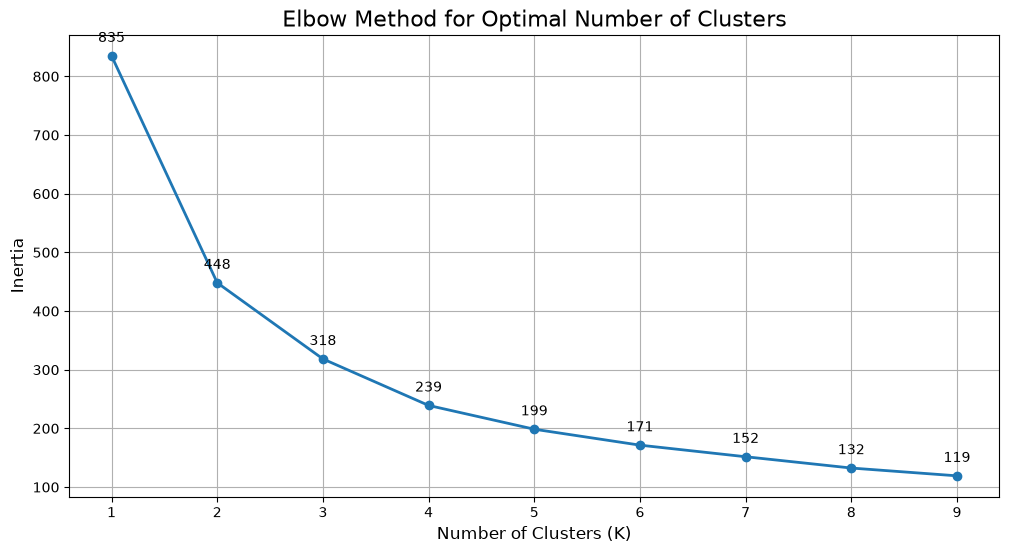

In [50]:
plt.figure(figsize=(12, 6))

plt.plot(
    K,
    inertias,
    marker='o',
    linewidth=2
)

for k, inertia in zip(K, inertias):
    plt.annotate(
        f'{inertia:.0f}',
        (k, inertia),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center'
    )

plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)

plt.title('Elbow Method for Optimal Number of Clusters', fontsize=16)

plt.xticks(K)

plt.grid(True)

plt.show()

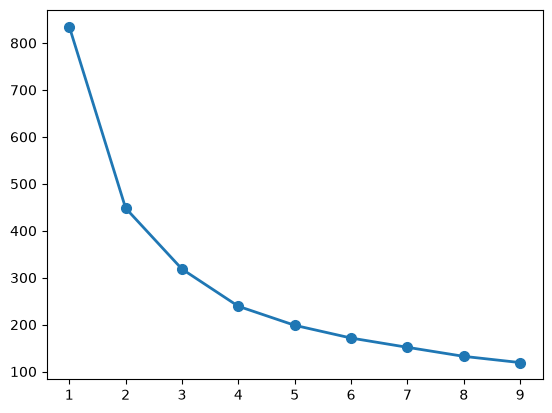

In [56]:
plt.plot(
    K,
    inertias,
    marker='o',
    linestyle='-',
    linewidth=2,
    markersize=7,
    label='Inertia'
)

In [64]:
kmeans = KMeans(n_clusters=3).fit(df) # df ichida malumotlar tahlil qilinadi va 3 ta klasterga ajtarilmoqda.
clusters = kmeans.labels_
clusters

array([0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       2, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)  # KMeans modelini yaratish va 3ta klasterga ajratish uchun n_clusters=3 ni belgilaymiz. random_state=42 esa natijaning qayta ishlashini tamilab beradi.
df['javob'] = kmeans.fit_predict(X) # fit modelni o'rganadi va predict esa yangi malumotlar asosida klasterni bashorat qiladi.

In [67]:
X = df.drop('javob', axis=1)
y = df['javob']

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [72]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [73]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0.   2.   0.   2.   1.01 1.   0.   1.   0.   0.  ]


In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.004411764705882356
RMSE: 0.018550408272025285
R²: 0.9994624324324324
